<!-- # Elife Paper 
## Figure 3: Success of the model
- A. Joing spectrogram of 4 syllables
- B. Trajectory plots for 4 syllables
- C. Detailed trajectory plot for 1 syllable
- D. Creating artifical landscapes with different number of distractors -->

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import json
import pickle
import queue
from scipy.integrate import solve_ivp
from dual_pathway_model.functions import *
from dual_pathway_model.directory_functions import *
from dual_pathway_model.model import NN, Environment, params_base
from dual_pathway_model.plotting_functions import *
import time

%load_ext autoreload


Base parameters loaded from params.yaml
Testing
Plotting colors safely loaded


In [2]:
# %autoreload 2
# from dual_pathway_model.functions import *
# from dual_pathway_model.directory_functions import *
# from dual_pathway_model.model import NN, Environment, params_base
# from dual_pathway_model.plotting_functions import *

### A. Song Spectrogram - 4 syllables joint plot

In [3]:
# ## Syrinx Spectrogram
# # np.random.seed(100)
# # Parameters
# gamma = 12000 

# duration = 0.050 #s
# dt = 1/44100 #s  #* 0.1 #1.e-4

# Amp = 10

# # Trachea parameters
# r=-0.9
# v=350*100
# L=1.9
# tau_0=2*L/v # Propagation time along trachea
# tau_n=int(tau_0/dt)
# # ks = np.linspace(0.16,0.52, 10)
# # ps = np.linspace(1852,2084, 10)

# # Track position and velocity 
# nt = int(duration/dt)
# X = np.zeros(nt)          # Labial position
# Y = np.zeros(nt)          # Velocity

# def sigmoid(x):
#       return 1 / (1 + np.exp(-x))

# def syrinxODE(t, y):
#     ''' ODEs used in Amador paper'''
    
#     y0, y1 = y
#     dydt = [y1,
#          -Pressure(t)*(gamma**2) - Tension(t)*(gamma**2)*y0 - (gamma**2)*(y0**3) - gamma*(y0**2)*y1 + (gamma**2)*(y0**2) - gamma*y0*y1
#            ]
#     return dydt

# # RC4
# # syllable 1
# syllable_array = [1,2,3,4]
# P_t_list = []  # <— add before the syllable loop




# for syllable in syllable_array:
#     if syllable == 1:
#         def Tension(t):
#             """ Generalised exponential waveform """
#             return   .3 - .2*np.exp(-200*t) -.00001 * np.exp(200*t) 

        
#         def Pressure(t):
#             """ Constant """
#             return 0.04*np.sin((duration/2 + t)*np.pi*10) + 0.05
#     # RC5 - test
#     elif syllable == 2:
#         # syllable 2
#         def Tension(t):
#             """ Generalised exponential waveform """
#             Tc = 1#2/3
#             return   .3 - .2*np.exp(-Tc*3*100*t) -.00001 * np.exp(Tc*3*100*t) 

#         def Pressure(t):
#             """ Constant """
#             tp = 0.2
#             return tp*np.sin((duration/2 + t)*np.pi*10) + 0.05
#     elif syllable == 3:
#         # syllable 3
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 1
#             if isinstance(t, float):
#                 if t <= duration*scale/2: 
#                     return 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
#                 elif t <= duration*scale: 
#                     return 10*np.sin((t-duration*scale/2)*np.pi*15/scale) + 0.6 # old amp 0.2
#                 else: 
#                     return 0.0 + 0*t
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 5*np.sin(t*np.pi*40/scale) + 0.6 # old amp 0.1
#                 Tension2 = 10*np.sin(t*np.pi*15/scale) + 0.6 # old amp 0.2
#                 Tension3 = 0.0 + 0*t
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale/2))], Tension2[:int(t.size*scale-t.size*scale/2)], Tension3[:int(t.size-t.size*scale)]))        
        
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 2 # old amp 0.16
#     elif syllable == 4:
#         # syllable 4
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 0.4
#             if isinstance(t, float):
#                 if t <= duration*scale: 
#                     return 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
#                 else: 
#                     return t*0 + 0.6 # old amp 0.2
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.8*np.sin(t*np.pi*20/scale) + 0.6 # old amp 0.1
#                 Tension2 = t* 0 + 0.6 # old amp 0.2
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale))], Tension2[:int(t.size-t.size*scale)]))
            
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.01
            
#     elif syllable == 5:
#         # syllable 5
#         def Tension(t):
#             """ Tension = 0.2 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.2
            
#         def Pressure(t):
#             """ Pressure = 0.1 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.1
#     elif syllable == 6:
#         # syllable 6
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             if isinstance(t, float):
#                 if t <= duration/2: return 0.1*np.sin(t*np.pi*40) + 0.6
#                 else: return 0.2*np.sin((t-duration/2)*np.pi*15) + 0.6
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.1*np.sin(t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(t*np.pi*15) + 0.6
#                 return np.concatenate((Tension1[:int(np.ceil(t.size/2))], Tension2[:int(t.size-t.size/2)]))
            
#         def Pressure(t):
#             """ Pressure = 0.01*np.sin(sin_t*np.pi*2*100) + 0.02 """
#             return 0.01*np.sin(t*np.pi*2*100) + 0.02
        

#     solution = solve_ivp(syrinxODE, [0, duration], [1, 1], method = "RK45", t_eval = np.linspace(0,duration,nt), rtol = 1e-8, atol = 1e-8)
#     # Extract labial position (X) and velocity (Y)
#     X = solution['y'][0]
#     Y = solution['y'][1]
#     # Transform into song
#     time_x = np.linspace(0, duration, nt)
#     song = Amp * Pressure(time_x) * Y
#     ## Trachea from Darshan, et. al. https://doi.org/10.1038/ncomms15415

#     # Input to trachea = output of syrinx
#     y0 = song.T

#     # To generate pressure output from trachea
#     P_i=np.zeros((len(y0)))

#     # See Fig 1 in Amador paper. Round-about way to implement that.
#     Buffer = queue.Queue()
#     for i in np.arange(tau_n):
#         Buffer.put(np.random.random())

#     for i in np.arange(len(y0)):
#         P_i[i] = y0[i] - r*Buffer.get();      
#         # update_buffer
#         Buffer.put(P_i[i])

#     # P_tr from P_in (ref Amador paper)
#     BufferB=np.zeros((tau_n))
#     P_tmp= np.concatenate((BufferB, P_i))
#     P_t=(1-r)*P_tmp[:-tau_n]
#     # ... inside your syllable loop, after computing P_t ...
#     P_t_list.append(P_t.copy())
#     time_x = np.linspace(0, duration, nt)




In [4]:
# # Parameters for panel width and labeling step
# seg = 0.05  # each subplot spans 0.05 s

# figure, axes = plt.subplots(
#     1, len(syllable_array),
#     figsize=(4*len(syllable_array), 6),
#     sharey=True, sharex=False,                 # sharey, but NOT sharex
#     gridspec_kw={'wspace': 0.09}               # tight horizontal spacing
# )

# # Ensure axes is always a list, even for single subplot
# if len(syllable_array) == 1:
#     axes = [axes]

# # Store spectrograms for each syllable
# spectrograms = []

# def fmt_tick(x):
#     s = f"{x:.2f}".rstrip('0').rstrip('.')
#     return s

# for i, syllable in enumerate(syllable_array):
#     # time window this panel represents in the global timeline
#     x0 = i * seg
#     x1 = (i + 1) * seg

#     # pick the right pressure trace for this syllable
#     P_src = P_t_list[i]  # assumes you appended in the simulation loop

#     # Generate spectrogram positioned in the global time coordinates
#     spectrumP, freqsP, t_bins, im = axes[i].specgram(
#         P_src, Fs=1/dt, NFFT=256, noverlap=128,
#         xextent=[x0, x1], cmap='inferno'
#     )

#     # Store spectrogram data
#     spectrograms.append({
#         "syllable": syllable,
#         "spectrum": spectrumP,
#         "freqs": freqsP,
#         "time": t_bins,
#         "image": im,
#         "xrange": (x0, x1),
#         "P_t": P_src
#     })

#     # Configure each subplot

#     axes[i].set_title(f'Syllable:{syllable}', fontsize=30)
#     axes[i].spines['top'].set_visible(False)
#     axes[i].spines['right'].set_visible(False)
#     axes[i].spines['bottom'].set_visible(False)
#     axes[i].set_ylim(0, 10000)
#     axes[i].set_xlim(x0, x1)
#     # axes[i].set_yticklabels

#     # ✅ Global-style ticks:
#     # Only left edge ticks, except last panel shows both left+right
#     if i < len(syllable_array) - 1:
#         axes[i].set_xticks([x0])
#         axes[i].set_xticklabels([fmt_tick(x0)])
#     else:
#         axes[i].set_xticks([x0, x1])
#         axes[i].set_xticklabels([fmt_tick(x0), fmt_tick(x1)])

#     # Y ticks
#     axes[i].set_yticks([0, 10000])
#     if i == 0:
#         axes[i].set_yticklabels([0, 10])
#     # else:
#         # axes[i].set_yticklabels([])  # cleaner, contiguous look

#     axes[i].tick_params(labelsize=25)
# # # After the for loop ends (all syllables plotted) ...

# # # Add one shared colorbar for the spectrograms
# # cbar = figure.colorbar(
# #     spectrograms[0]["image"],    # use the first specgram’s image handle
# #     ax=axes,
# #     orientation='vertical',
# #     fraction=0.02,               # size of colorbar
# #     pad=0.04                     # distance from plots
# # )

# # cbar.set_label("Power (dB)", fontsize=20)
# # cbar.ax.tick_params(labelsize=15)

# # Set labels only on the leftmost subplot
# axes[0].set_ylabel('Frequency (kHz)', fontsize=30)
# figure.supxlabel('Time (s)', fontsize=30, y = -0.05)
# # plt.tight_layout()
# # figure.subplots_adjust(wspace=0.1)  # extra-tight spacing between panels
# plt.show()


### B: Syrinx 4 syllables learning


In [5]:
# # load parameters and update with any changes


parameters = update_params(params_base, 
                               **{
                                   "params.LANDSCAPE": 1,
                                    # "params.DAYS": 60,
                               }
                               )
# running conditions
TRIALS = parameters['params']['TRIALS'] 
DAYS = parameters['params']['DAYS'] 
N_SYLL = parameters['params']['N_SYLL']
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
# RANDOM_SEED = 36937 # 11878 # 80674 # 80024 # 93392 # 1454 - another ok one    
RANDOM_SEED = 36937 # int(time.time() * 1000) % 100000  # system-time-based seed

print(f'Random seed is {RANDOM_SEED}')

Random seed is 36937


In [6]:
# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3b" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3b = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3b = Environment(RANDOM_SEED, parameters, NN)
        obj_3b.run(parameters)
        if save_model:
            with open(model_path, "wb") as f:
                pickle.dump(obj_3b, f)
            print(f"Saved model '{model_version}'")
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3b = Environment(RANDOM_SEED, parameters, NN)
    obj_3b.run(parameters)
    if save_model:
        with open(model_path, "wb") as f:
            pickle.dump(obj_3b, f)
        print(f"Saved model '{model_version}'")

Model 'model_3b' already exists.
Loading existing model...
Loaded model 'model_3b'


Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


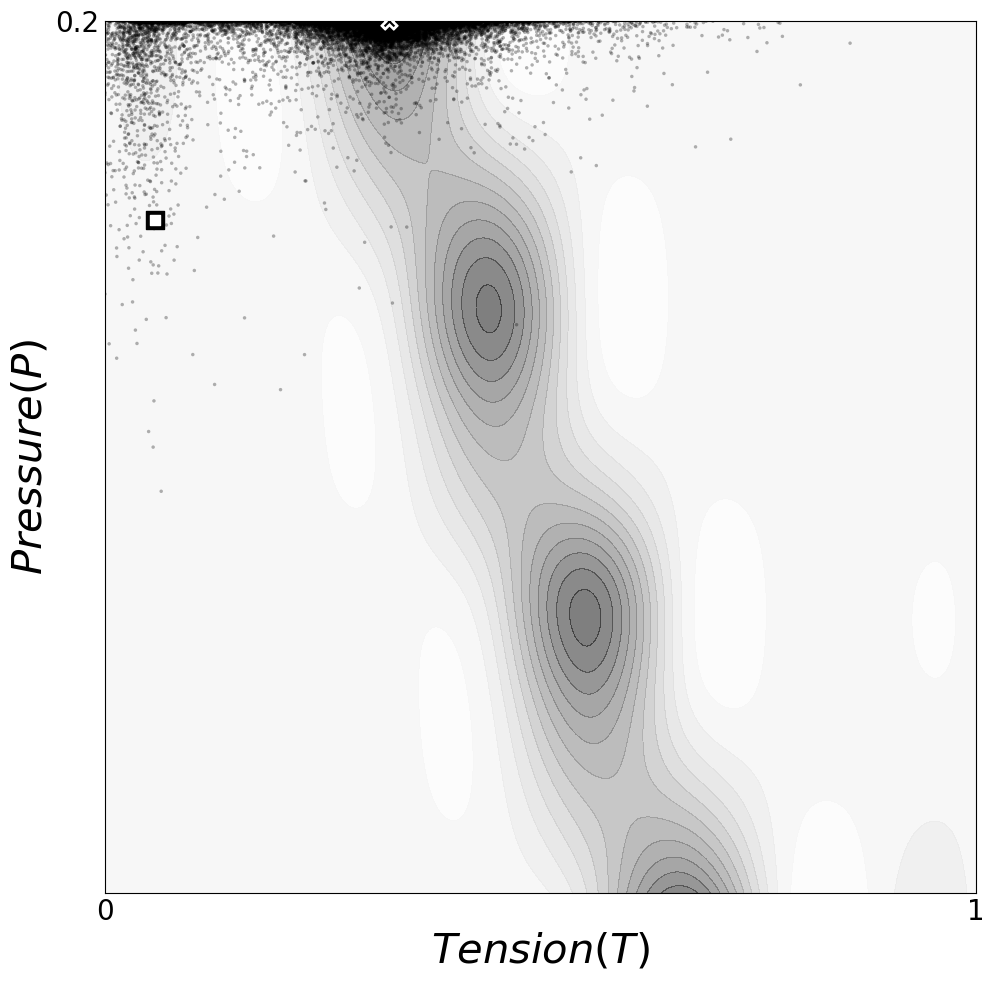

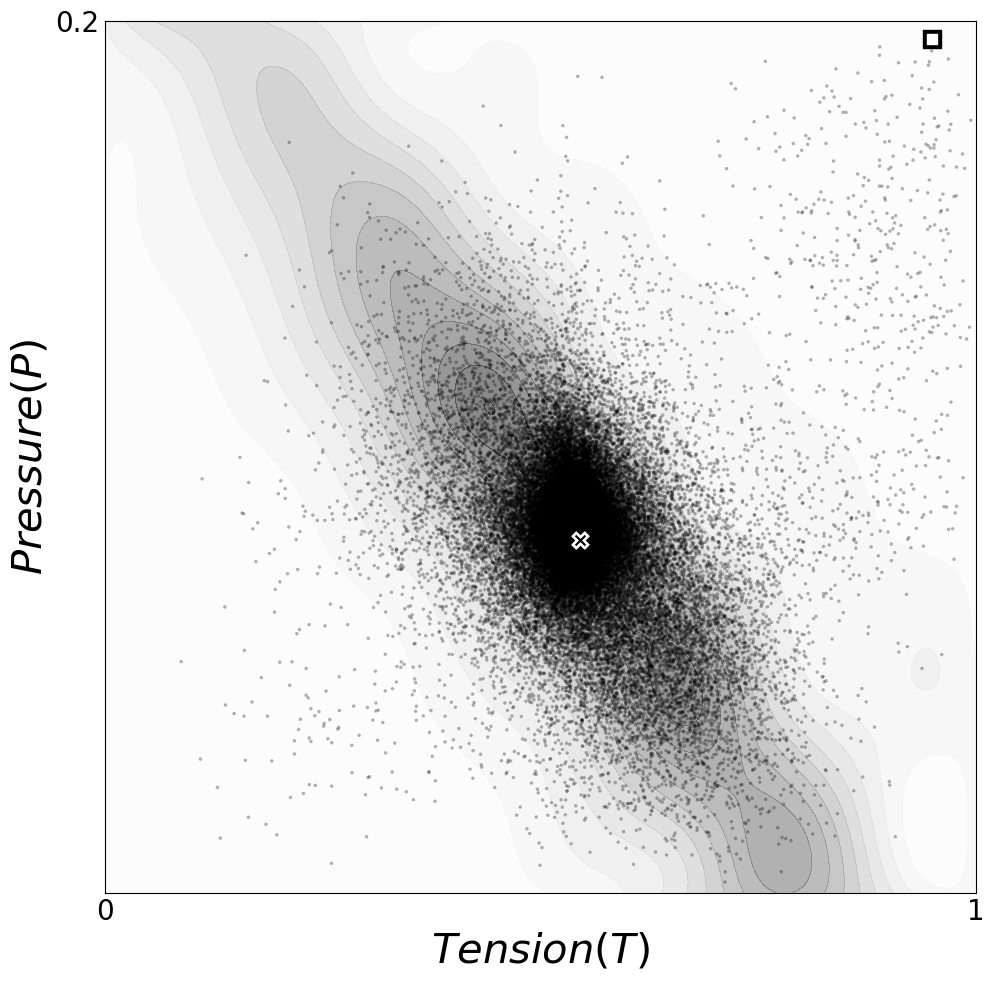

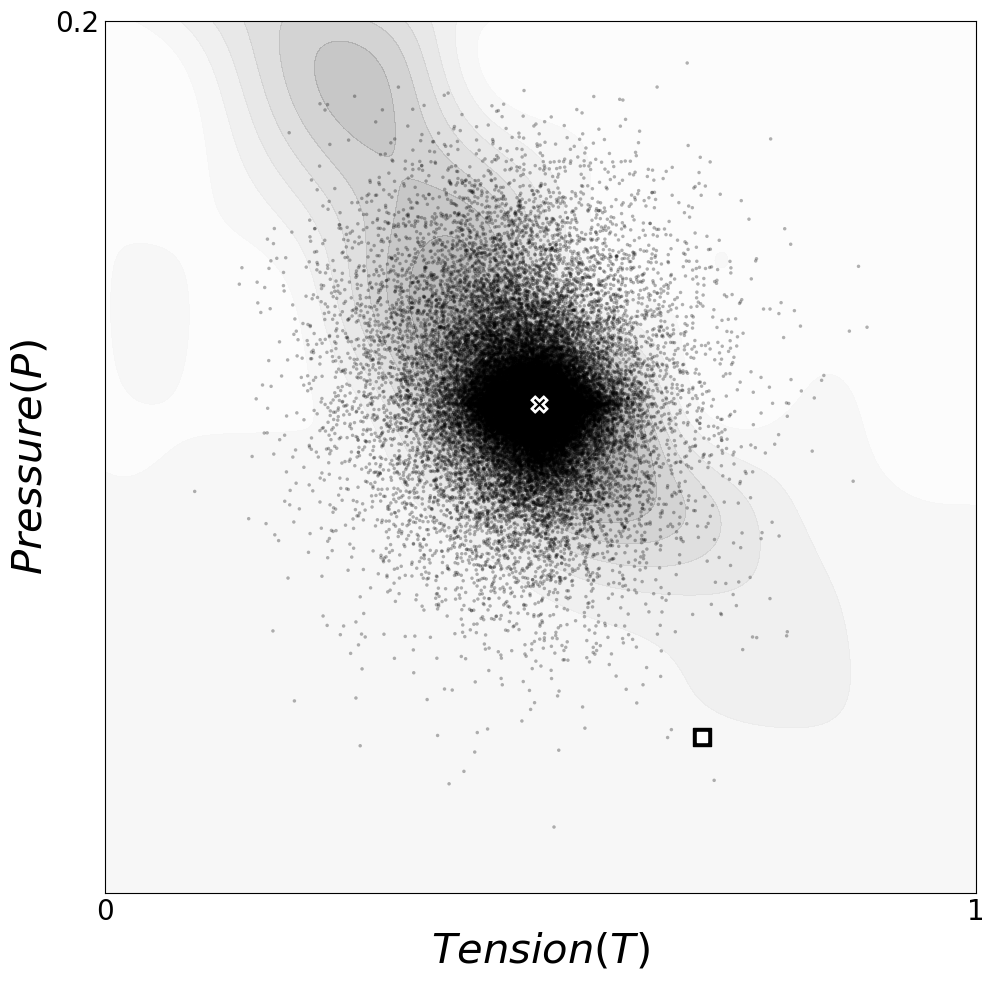

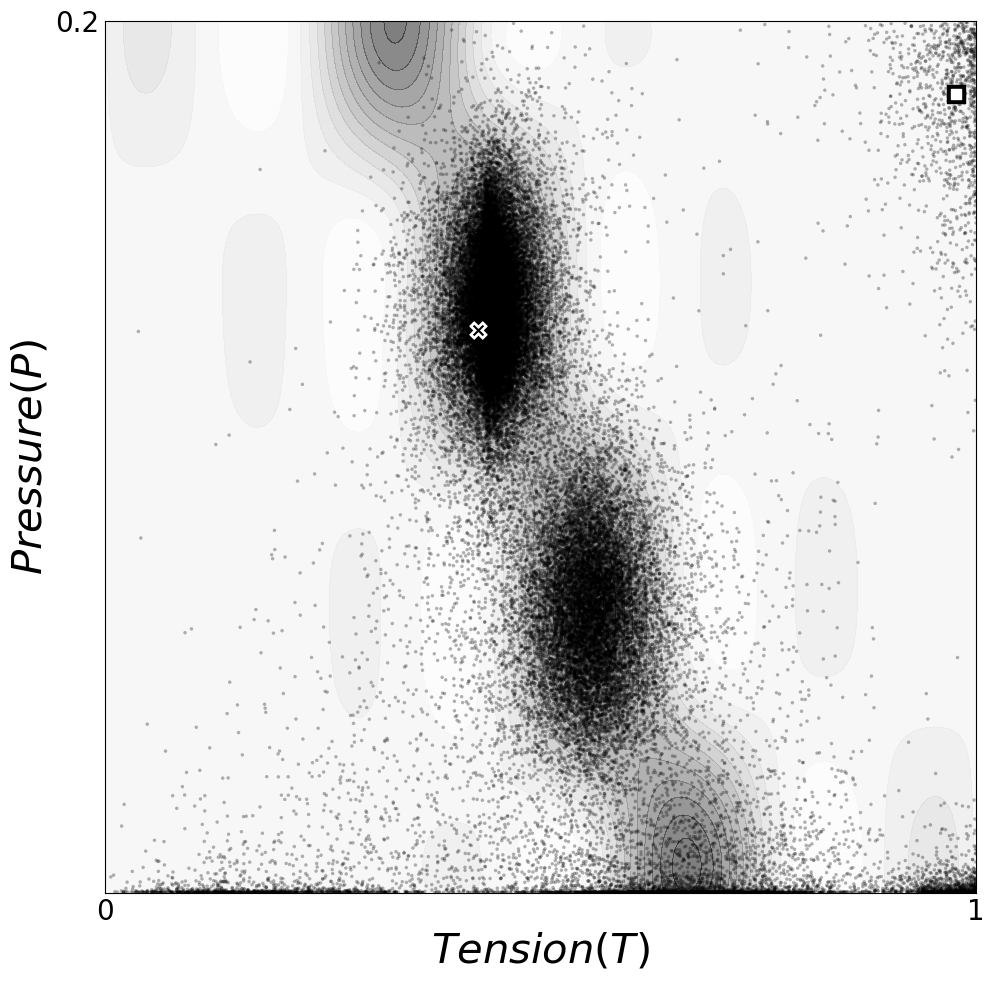

In [7]:
# %autoreload 2
# from dual_pathway_model.plotting_functions import *

# N_SYLL =  obj_3b.N_SYLL

# for i in [1]: # Change to N_SYLL for all syllables
for i in range(N_SYLL):
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=False)

    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_3b_syll_{i}.svg"), dpi=600, bbox_inches="tight")

Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


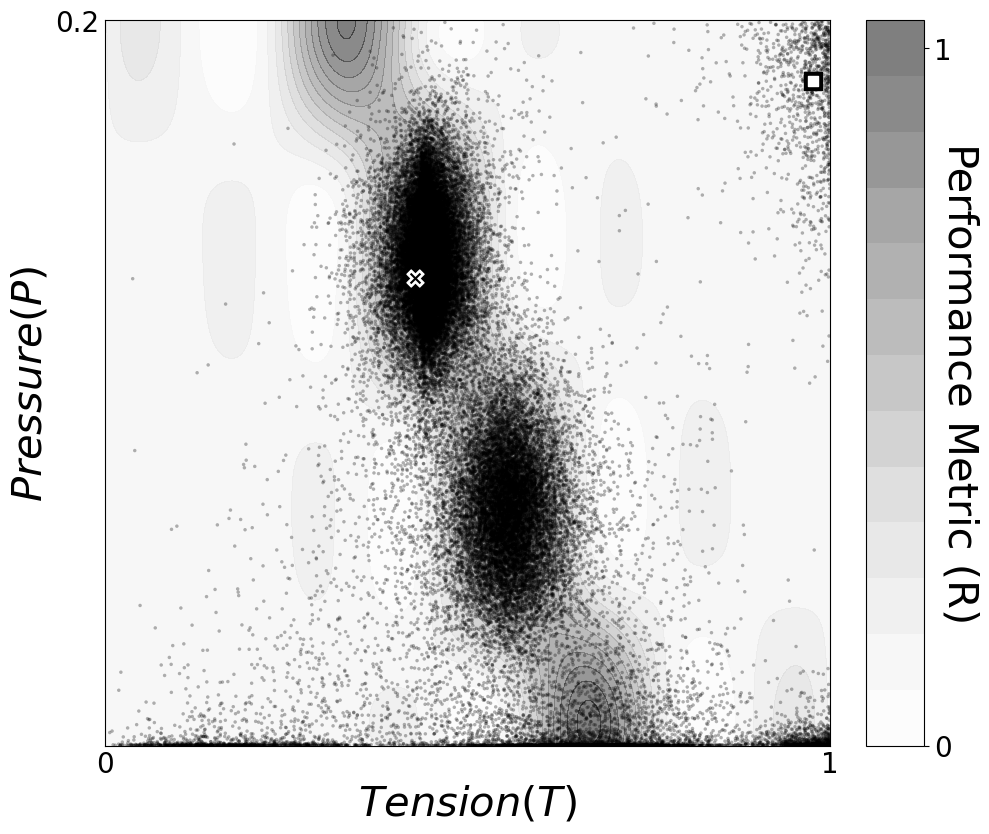

In [8]:
# %autoreload 2
# from dual_pathway_model.plotting_functions import *


# for i in [1]: # Change to N_SYLL for all syllables
for i in [3]:
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=True, legend=False)

    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_3b_syll_{i}_colorbar.svg"), dpi=600, bbox_inches="tight")

Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


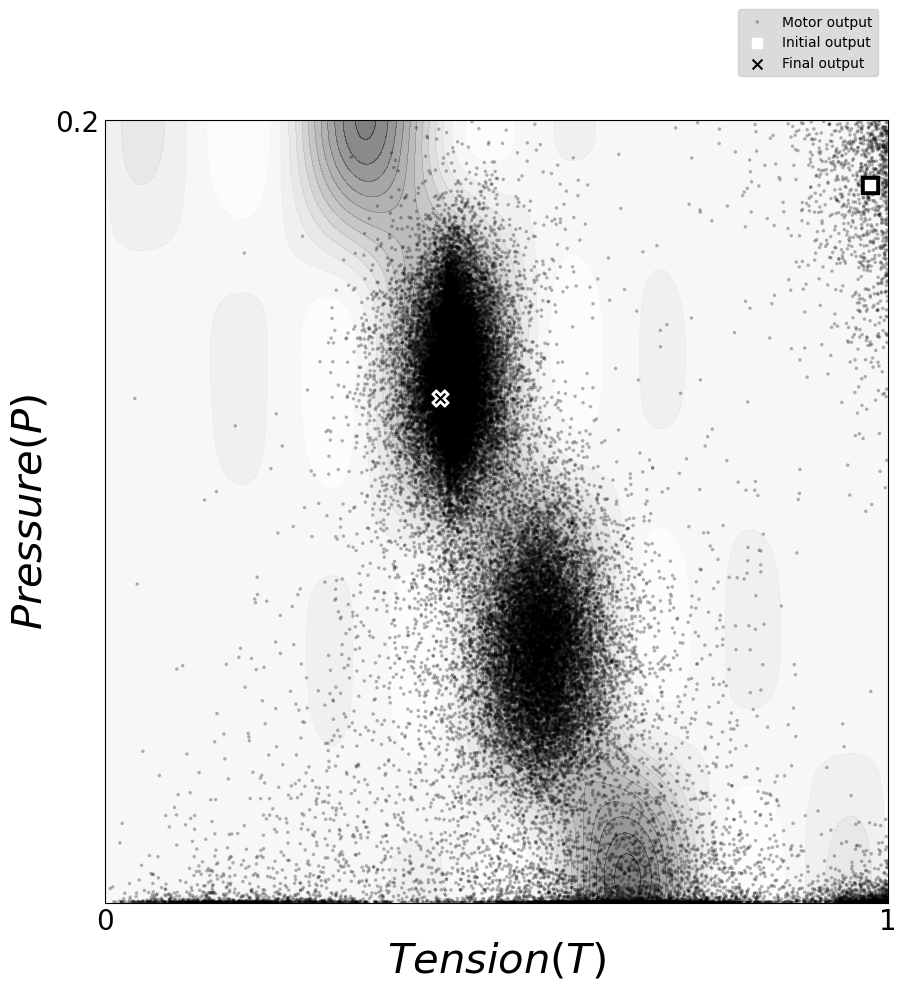

In [9]:
# %autoreload 2
# from dual_pathway_model.plotting_functions import *


# for i in [1]: # Change to N_SYLL for all syllables
for i in [3]:
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True, colorbar=False, legend=True)

    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_3b_syll_{i}_legend.svg"), dpi=600, bbox_inches="tight")

<!-- Alternate 2D plotting style -->

### C. Detailed trajectory plot for 1 syllable

In [10]:
# parameters = update_params(params_base,
#                            **{
#                                "params.LANDSCAPE": 1,
#                                "params.N_SYLL": 4
#                            } )
                           
# # running conditions
# N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
# TRIALS = N_DAILY_MOTIFS
# BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
# DAYS = parameters['params']['DAYS'] # days for learning
# N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
# if N_SYLL > 5 or N_SYLL < 1:
#     ValueError('Invalid number of syllables')
# RANDOM_SEED = RANDOM_SEED # 40
# ANNEALING = parameters['params']['ANNEALING'] # annealing 
# print(f'Random seed is {RANDOM_SEED}')

In [11]:
# # --------------------
# # Config
# # --------------------
# MODEL_DIR = "models"
# model_version = "model_3c" # 
# model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
# overwrite_model = True # whether to overwrite existing model or not
# save_model = False # whether to save model after running simulation or not
# # --------------------
# # Ensure models/ exists
# # --------------------
# os.makedirs(MODEL_DIR, exist_ok=True)

# # --------------------
# # Load / run / overwrite logic
# # --------------------
# if os.path.exists(model_path):
#     print(f"Model '{model_version}' already exists.")
#     if not overwrite_model:
#         print("Loading existing model...")
#         with open(model_path, "rb") as f:
#             obj_3c = pickle.load(f)
#         print(f"Loaded model '{model_version}'")
#     else:
#         print("Overwrite enabled. Re-running simulation and overwriting model...")
#         print(f"Model '{model_version}' not found. Running simulation...")
#         obj_3c = Environment(RANDOM_SEED, parameters, NN)
#         obj_3c.run(parameters)
#         if save_model:
#             with open(model_path, "wb") as f:
#                 pickle.dump(obj_3c, f)
#             print(f"Saved model '{model_version}'")
# else:
#     print(f"Model '{model_version}' not found. Running simulation...")
#     obj_3c = Environment(RANDOM_SEED, parameters, NN)
#     obj_3c.run(parameters)
#     if save_model:
#         with open(model_path, "wb") as f:
#             pickle.dump(obj_3c, f)
#         print(f"Saved model '{model_version}'")


Plotting syrinx landscape


C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:245: UserWarning: The following kwargs were not used by contour: 'aspect'
  cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], aspect='equal', vmin=0, vmax=1, levels=levels_, alpha=contour_alpha)


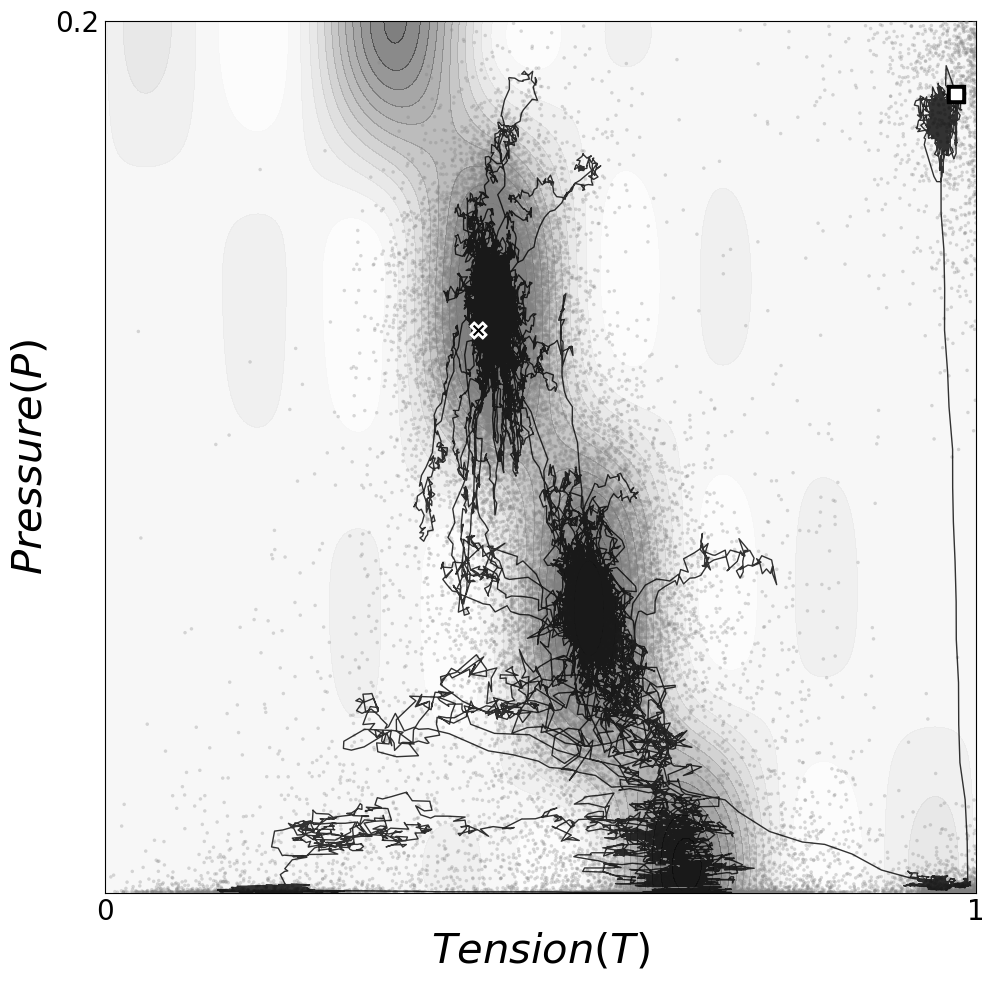

In [12]:
# %autoreload 2
# from dual_pathway_model.plotting_functions import *

for i in [3]: #range(N_SYLL):
# for i in range(N_SYLL):
    plot_scatter_traj(obj = obj_3b, syll=i, day_i=0, day_f=60, every_nth_point=1, scatter_alpha=0.3, if_contour=False, contour_alpha=.5, heatmap=True,
                    plot_smooth_traj=True)  # To remove smoothened trajectory, set plot_smooth_traj=False

    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_3c_syll_{i}.svg"), dpi=600, bbox_inches="tight")

C:\Users\rsankar\Desktop\DualPathwayFigures\Repo20Feb2026\Dual_Pathway_RL_songbird\src\dual_pathway_model\plotting_functions.py:522: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False, loc='center right', fontsize=12, bbox_to_anchor=(1.03,1))


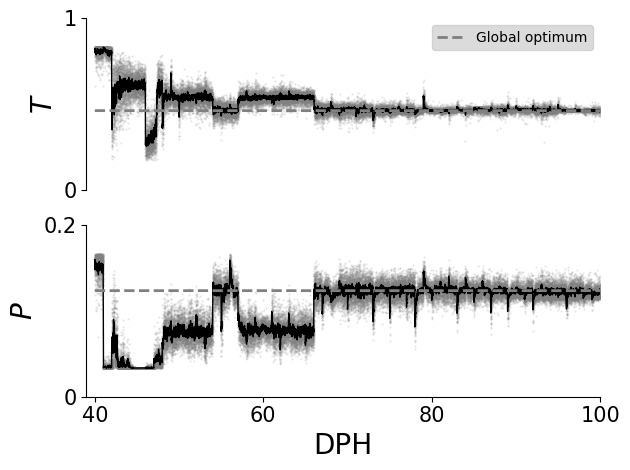

In [13]:
# %autoreload 2
# from dual_pathway_model.plotting_functions import *

# for i in range(N_SYLL):
for i in [3]:
    plot_output(obj_3b, i, skip_size=1, window_size=20)
    
    os.makedirs("Plots", exist_ok=True)
    plt.savefig(os.path.join("Plots", f"landscape_3d_syll_{i}.svg"), dpi=600, bbox_inches="tight")

### D. Performance over 4 syllables in a motif


syllable
[WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Figures/results/multi_syllable')]


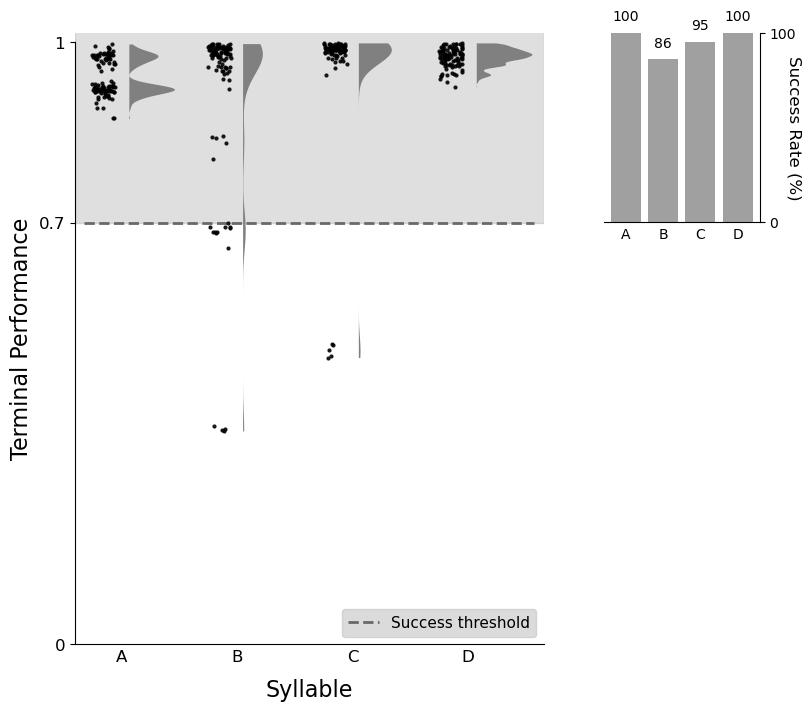

In [14]:
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "results"

result_folders = find_subdirectories(results_dir, absolute=True)
selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    print(param_name)
    selected_folders.append((folder))
print(selected_folders)
terminal_performance = {}
meta = {}

for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)


terminal_performance['syllable'].shape, meta['syllable'].keys()
# Example call
plot_results_violin(
    terminal_performance["syllable"], 
    np.arange(terminal_performance["syllable"].shape[1]),  # dummy x values for violin plot
    big_xlabel="Syllable",
    xticklabels=['A', 'B', 'C', 'D'],
    xticklabel_rotation=0,
    print_success_rate=True,
    height_ratio=[2.4, 5]
)


os.makedirs("Plots", exist_ok=True)
plt.savefig(os.path.join("Plots", f"robustness_3e_syll_{i}.svg"), dpi=600, bbox_inches="tight")


### E. Different number of distractors
Modify this `plot_landscape` function to change the appearance. 

In [15]:
# %autoreload 2
# from dual_pathway_model.functions import *
# from dual_pathway_model.directory_functions import *
# from dual_pathway_model.model import NN, Environment, params_base
# from dual_pathway_model.plotting_functions import *

Selected folders: [WindowsPath('C:/Users/rsankar/Desktop/DualPathwayFigures/Repo20Feb2026/Dual_Pathway_RL_songbird/Robustness/results/params_N_DISTRACTORS')]


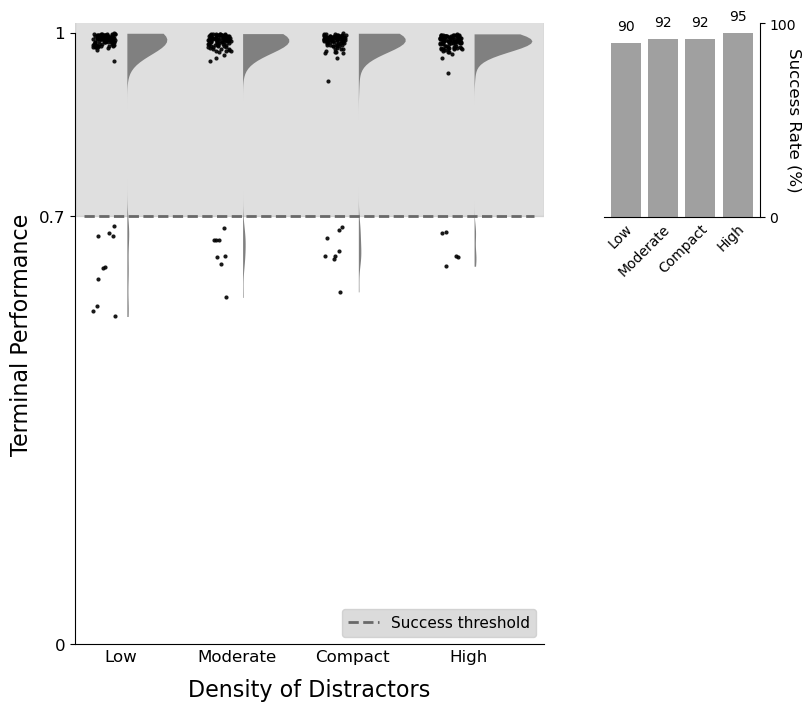

In [16]:



wanted_parameters = ["N_DISTRACTORS"]
HERE = Path.cwd()          # notebook directory
results_dir = HERE / "../Robustness/results"

result_folders = find_subdirectories(results_dir, absolute=True)

selected_folders = []
for folder in result_folders:
    param_name = extract_param_name(folder)
    if param_name in wanted_parameters:
        selected_folders.append(folder)
print("Selected folders:", selected_folders)

terminal_performance = {}
meta = {}


for folder in selected_folders:
    param = extract_param_name(folder)

    perf_path = folder / "terminal_performance.npy"
    meta_path = folder / "meta.yaml"

    if not perf_path.exists() or not meta_path.exists():
        print(f"⚠️ Skipping {folder.name} (missing files)")
        continue

    terminal_performance[param] = np.load(perf_path)

    with open(meta_path, "r") as f:
        meta[param] = yaml.safe_load(f)
terminal_performance['N_DISTRACTORS'].shape, meta['N_DISTRACTORS'].keys()

plot_results_violin(
    terminal_performance["N_DISTRACTORS"], 
    meta["N_DISTRACTORS"]["values"],
    big_xlabel="Density of Distractors",
    xticklabels=['Low', 'Moderate', 'Compact', 'High'],
    xticklabel_rotation=45,
    print_success_rate=True,
    height_ratio=[2.7, 5]
)



os.makedirs("Plots", exist_ok=True)
plt.savefig(os.path.join("Plots", f"robustness_3f_syll_{i}.svg"), dpi=600, bbox_inches="tight")

In [17]:
# def plot_lansdcape(syll, force_landscape=False, landscape=1):
#     fig, axs = plt.subplots(figsize=(9, 9))
#     cmap = color_contour_bckg #LinearSegmentedColormap.from_list('white_to_black', ['white', 'rebeccapurple'])
#     levels_ = 50
#     def plot_artificial():
#         limit = obj.limit
#         x, y = np.linspace(-limit, limit, 50), np.linspace(-limit, limit, 50)
#         X, Y = np.meshgrid(x, y)
#         Z = obj.get_reward([X, Y], syll)
#         contour = axs.contourf(X, Y, Z, levels=levels_, cmap=cmap)
#         if if_contour:
#             axs.contour(X, Y, Z, levels=15, colors='k', linewidths=1, alpha=0.9)
#         # cbar = fig.colorbar(contour, ax=axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation = 270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0,1])

#         axs.set_xticks([-limit, 0, limit], [-1, 0, 1])
#         axs.set_yticks([-limit, 0, limit], [-1, 0, 1])

#     def plot_syrinx():
#         if obj.N_SYLL > 4:
#             raise ValueError('Only 4 syllables are available in the syrinx landscape')
#         obj.syrinx_contours = []
#         obj.syrinx_targets = []
#         for j in range(obj.N_SYLL):
#             base = np.load(f"contours/Syll{j+1}.npy")
#             Z, target = make_contour(base)
#             obj.syrinx_contours.append(Z)
#             obj.syrinx_targets.append(target)
#         obj.centers = np.array(obj.syrinx_targets)
#         obj.syrinx_contours = np.array(obj.syrinx_contours)
#         Z = obj.syrinx_contours[syll]
#         target_pos = obj.syrinx_targets[syll]
#         if if_contour:
#             axs.contour(Z.T, levels=15, extent=[-1, 1, -1, 1], colors='k', linewidths=1, alpha=1)
#         cs = axs.contourf(Z.T, cmap=cmap, extent=[-1, 1, -1, 1], levels=levels_)
#         # cbar = fig.colorbar(cs, ax = axs)
#         # cbar.set_label('Performance Metric (R)', fontsize=20, rotation = 270)
#         # cbar.ax.tick_params(labelsize=18)
#         # cbar.ax.set_yticks([0,1])
#         axs.set_xticks([-1, 1], [0, 1])
#         axs.set_yticks([-1,1], [0, 0.2])
#         # axs.scatter(target_pos[1], target_pos[0], s=100, c='green', marker='x', label='Target')

#     if not force_landscape:
#         if obj.LANDSCAPE == 0:
#             print("No force artificial landscape")
#             plot_artificial()
#         else:
#             plot_syrinx()
#     else:
#         if landscape == 0:
#             plot_artificial()
#         else:
#             plot_syrinx()

#     # axs.set_ylabel(r'$P_{\alpha}$', fontsize=22)
#     # axs.set_xlabel(r'$P_{\beta}$', fontsize=22)
#     axs.set_ylabel(r'$P$', fontsize=22)
#     axs.set_xlabel(r'$T$', fontsize=22)
#     axs.tick_params(labelsize=16)
#     axs.legend()
#     plt.tight_layout()
#     plt.show()

1
Random seed is 42
Model 'model_3e1' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 1996.34it/s]

Plotting artificial landscape


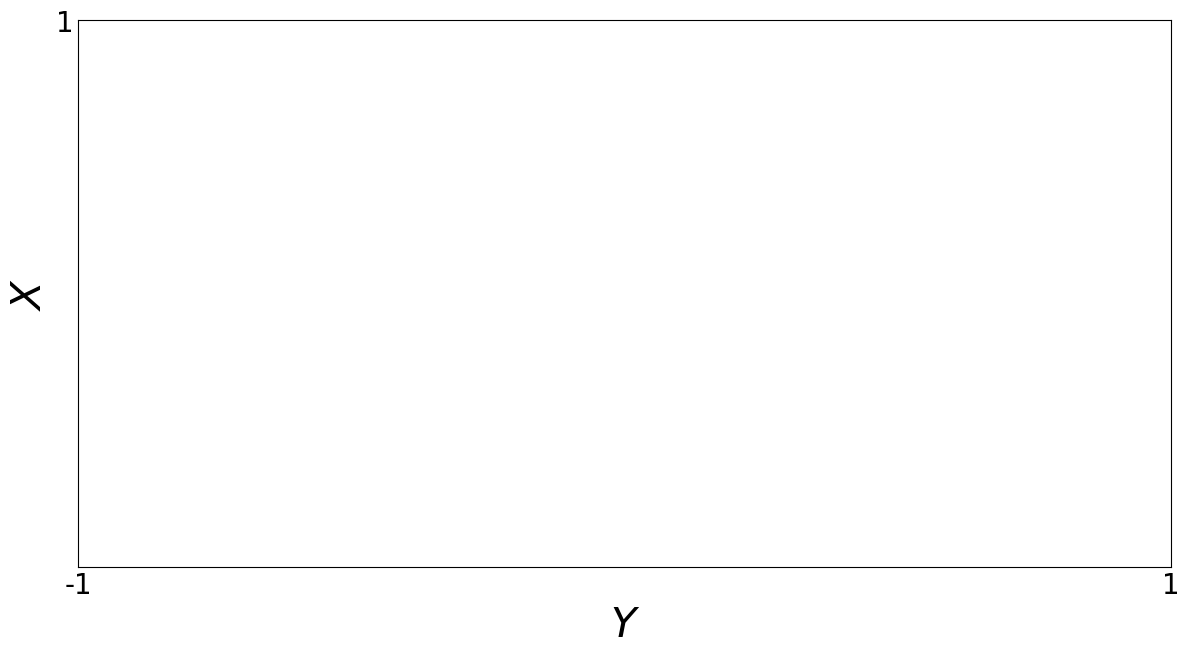

In [18]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 5
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e1" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e1 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e1 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e1.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e1 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e1.run(parameters)

plot_landscape_only(obj_3e1, syll=0)

1
Random seed is 42
Model 'model_3e2' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 824.68it/s]

Plotting artificial landscape


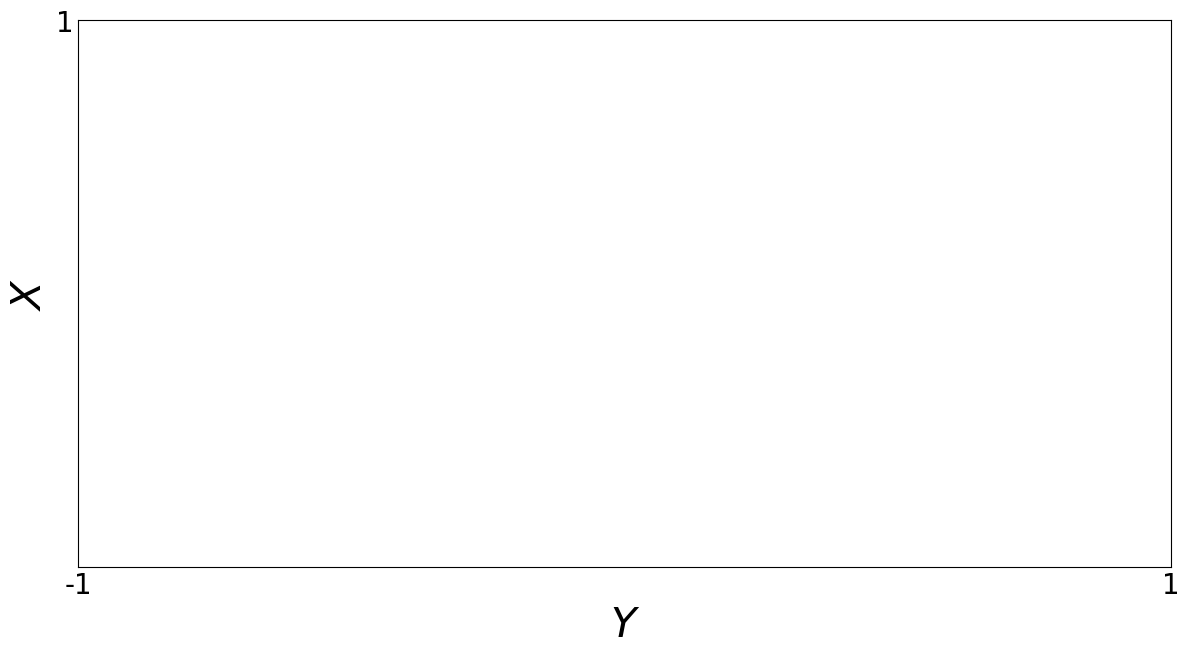

In [19]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 10
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e2" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e2 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e2 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e2.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e2 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e2.run(parameters)

plot_landscape_only(obj_3e2, syll=0)

1
Random seed is 42
Model 'model_3e3' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 857.29it/s]

Plotting artificial landscape


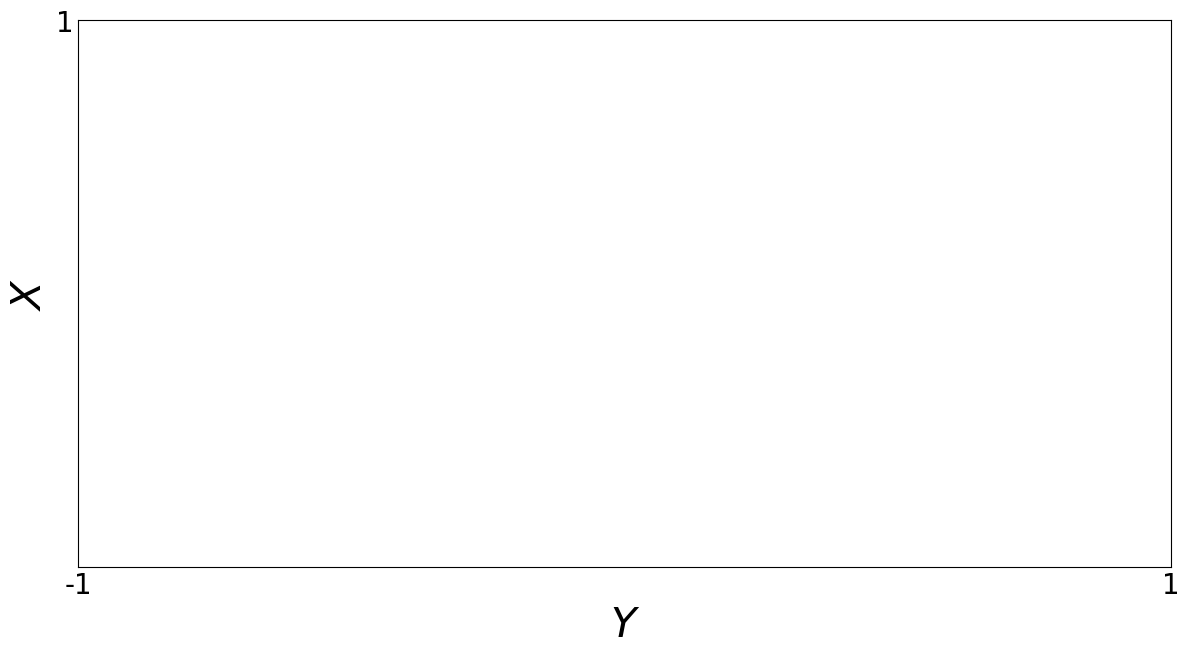

In [20]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 20
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e3" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e3 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e3 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e3.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e3 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e3.run(parameters)

plot_landscape_only(obj_3e3, syll=0)

1
Random seed is 42
Model 'model_3e4' not found. Running simulation...


100%|██████████| 2/2 [00:00<00:00, 667.56it/s]

Plotting artificial landscape


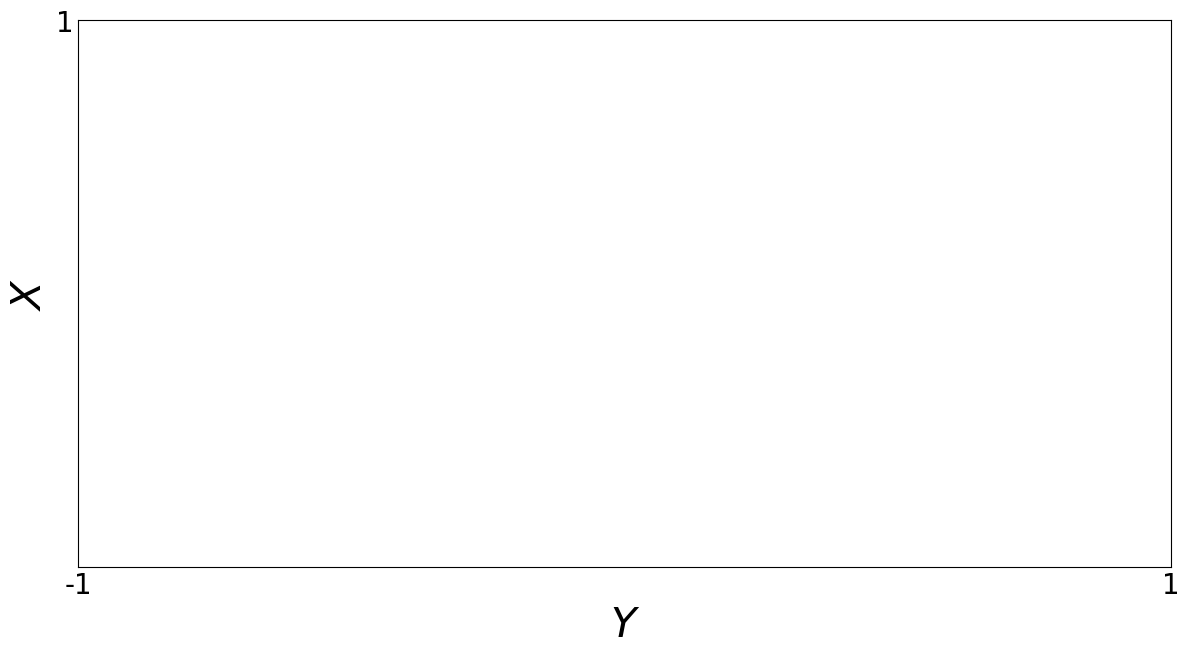

In [21]:
# # load parameters from json file
# params_path = "params_3_5.json"
# # Open the file and read the contents
# with open(params_path, "r") as f:
#     parameters = json.load(f)

parameters = update_params(params_base,
                           **{
                               "params.N_SYLL": 1,
                               "params.DAYS": 2,
                               "params.TRIALS": 2,
                               "params.N_DISTRACTORS": 50
                           } )


# running conditions
N_DAILY_MOTIFS = parameters['params']['TRIALS'] # trials per day per syllable  # old code TRIALS
TRIALS = N_DAILY_MOTIFS
BG_INTACT_DAYS = parameters['params']['BG_INTACT_DAYS']
DAYS = parameters['params']['DAYS'] # days for learning
N_SYLL = parameters['params']['N_SYLL'] # number of syllables   
if N_SYLL > 5 or N_SYLL < 1:
    ValueError('Invalid number of syllables')
RANDOM_SEED = 42
ANNEALING = parameters['params']['ANNEALING'] # annealing 
print(ANNEALING) 
print(f'Random seed is {RANDOM_SEED}')

# --------------------
# Config
# --------------------
MODEL_DIR = "models"
model_version = "model_3e4" # 
model_path = os.path.join(MODEL_DIR, f"{model_version}.pkl")
overwrite_model = False # whether to overwrite existing model or not
save_model = False # whether to save model after running simulation or not
# --------------------
# Ensure models/ exists
# --------------------
os.makedirs(MODEL_DIR, exist_ok=True)

# --------------------
# Load / run / overwrite logic
# --------------------
if os.path.exists(model_path):
    print(f"Model '{model_version}' already exists.")
    if not overwrite_model:
        print("Loading existing model...")
        with open(model_path, "rb") as f:
            obj_3e4 = pickle.load(f)
        print(f"Loaded model '{model_version}'")
    else:
        print("Overwrite enabled. Re-running simulation and overwriting model...")
        print(f"Model '{model_version}' not found. Running simulation...")
        obj_3e4 = Environment(RANDOM_SEED, parameters, NN)
        obj_3e4.run(parameters)
else:
    print(f"Model '{model_version}' not found. Running simulation...")
    obj_3e4 = Environment(RANDOM_SEED, parameters, NN)
    obj_3e4.run(parameters)

plot_landscape_only(obj_3e4, syll=0)

<!-- ### Spectrograms of maxima's
Change the value of P_alpha and T_beta from 0,0 to something else -->

In [22]:
# P_alpha, T_beta = 0.5, 0.3

In [23]:
# np.random.seed(100)
# # Parameters
# gamma = 12000 

# duration = 0.050 #s
# dt = 1/44100 #s  #* 0.1 #1.e-4

# Amp = 10

# # Trachea parameters
# r=-0.9
# v=350*100
# L=1.9
# tau_0=2*L/v # Propagation time along trachea
# tau_n=int(tau_0/dt)
# # ks = np.linspace(0.16,0.52, 10)
# # ps = np.linspace(1852,2084, 10)

# # Track position and velocity 
# nt = int(duration/dt)
# X = np.zeros(nt)          # Labial position
# Y = np.zeros(nt)          # Velocity

# def sigmoid(x):
#       return 1 / (1 + np.exp(-x))

# def syrinxODE(t, y):
#     ''' ODEs used in Amador paper'''
    
#     y0, y1 = y
#     dydt = [y1,
#          -Pressure(t)*(gamma**2) - Tension(t)*(gamma**2)*y0 - (gamma**2)*(y0**3) - gamma*(y0**2)*y1 + (gamma**2)*(y0**2) - gamma*y0*y1
#            ]
#     return dydt

# # RC4
# # syllable 1
# syllable_array = [1]
# P_t_list = []  # <— add before the syllable loop




# for syllable in syllable_array:
#     if syllable == 1:
#         def Tension(t):
#             """ Generalised exponential waveform """
#             return   .3 - .2*np.exp(-200*t) -.00001 * np.exp(200*t) + T_beta

        
#         def Pressure(t):
#             """ Constant """
#             return 0.04*np.sin((duration/2 + t)*np.pi*10) + 0.05 + P_alpha
#     # RC5 - test
#     elif syllable == 2:
#         # syllable 2
#         def Tension(t):
#             """ Generalised exponential waveform """
#             Tc = 1#2/3
#             return   .3 - .2*np.exp(-Tc*3*100*t) -.00001 * np.exp(Tc*3*100*t) + T_beta

#         def Pressure(t):
#             """ Constant """
#             tp = 0.2
#             return tp*np.sin((duration/2 + t)*np.pi*10) + 0.05 + P_alpha
#     elif syllable == 3:
#         # syllable 3
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 1
#             if isinstance(t, float):
#                 if t <= duration*scale/2: 
#                     return 5*np.sin(t*np.pi*40/scale) + 0.6 + T_beta # old amp 0.1
#                 elif t <= duration*scale: 
#                     return 10*np.sin((t-duration*scale/2)*np.pi*15/scale) + 0.6 + T_beta# old amp 0.2
#                 else: 
#                     return 0.0 + 0*t + T_beta
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 5*np.sin(t*np.pi*40/scale) + 0.6 + T_beta# old amp 0.1
#                 Tension2 = 10*np.sin(t*np.pi*15/scale) + 0.6 + T_beta# old amp 0.2
#                 Tension3 = 0.0 + 0*t + T_beta
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale/2))], Tension2[:int(t.size*scale-t.size*scale/2)], Tension3[:int(t.size-t.size*scale)]))        
        
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 2  + P_alpha # old amp 0.16
#     elif syllable == 4:
#         # syllable 4
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             scale = 0.4
#             if isinstance(t, float):
#                 if t <= duration*scale: 
#                     return 0.8*np.sin(t*np.pi*20/scale) + 0.6 + T_beta # old amp 0.1
#                 else: 
#                     return t*0 + 0.6 + T_beta # old amp 0.2
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.8*np.sin(t*np.pi*20/scale) + 0.6 + T_beta # old amp 0.1
#                 Tension2 = t* 0 + 0.6 + T_beta # old amp 0.2
#                 return np.concatenate((Tension1[:int(np.ceil(t.size*scale))], Tension2[:int(t.size-t.size*scale)]))
            
#         def Pressure(t):
#             """ Pressure = 0.02 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.01 + P_alpha
            
#     elif syllable == 5:
#         # syllable 5
#         def Tension(t):
#             """ Tension = 0.2 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.2
            
#         def Pressure(t):
#             """ Pressure = 0.1 * np.ones((nt)) """
#             return np.ones((np.asarray(t).shape)) * 0.1
#     elif syllable == 6:
#         # syllable 6
#         def Tension(t):
#             """
#                 Tension1 = 0.1*np.sin(sin_t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(sin_t*np.pi*15) + 0.6
#                 Tension = np.concatenate((Tension1[:int(np.ceil(nt/2))], Tension2[:int(nt-nt/2)]))
#             """
#             if isinstance(t, float):
#                 if t <= duration/2: return 0.1*np.sin(t*np.pi*40) + 0.6
#                 else: return 0.2*np.sin((t-duration/2)*np.pi*15) + 0.6
#             elif isinstance(t, np.ndarray):
#                 Tension1 = 0.1*np.sin(t*np.pi*40) + 0.6
#                 Tension2 = 0.2*np.sin(t*np.pi*15) + 0.6
#                 return np.concatenate((Tension1[:int(np.ceil(t.size/2))], Tension2[:int(t.size-t.size/2)]))
            
#         def Pressure(t):
#             """ Pressure = 0.01*np.sin(sin_t*np.pi*2*100) + 0.02 """
#             return 0.01*np.sin(t*np.pi*2*100) + 0.02
        

#     solution = solve_ivp(syrinxODE, [0, duration], [1, 1], method = "RK45", t_eval = np.linspace(0,duration,nt), rtol = 1e-8, atol = 1e-8)
#     # Extract labial position (X) and velocity (Y)
#     X = solution['y'][0]
#     Y = solution['y'][1]
#     # Transform into song
#     time_x = np.linspace(0, duration, nt)
#     song = Amp * Pressure(time_x) * Y
#     ## Trachea from Darshan, et. al. https://doi.org/10.1038/ncomms15415

#     # Input to trachea = output of syrinx
#     y0 = song.T

#     # To generate pressure output from trachea
#     P_i=np.zeros((len(y0)))

#     # See Fig 1 in Amador paper. Round-about way to implement that.
#     Buffer = queue.Queue()
#     for i in np.arange(tau_n):
#         Buffer.put(np.random.random())

#     for i in np.arange(len(y0)):
#         P_i[i] = y0[i] - r*Buffer.get();      
#         # update_buffer
#         Buffer.put(P_i[i])

#     # P_tr from P_in (ref Amador paper)
#     BufferB=np.zeros((tau_n))
#     P_tmp= np.concatenate((BufferB, P_i))
#     P_t=(1-r)*P_tmp[:-tau_n]
#     # ... inside your syllable loop, after computing P_t ...
#     P_t_list.append(P_t.copy())
#     time_x = np.linspace(0, duration, nt)

In [24]:
# for i in range(len(syllable_array)):
#     P_t = P_t_list[i]
#     figure, ax = plt.subplots(1)

#     (spectrumP, freqsP, t, im) = plt.specgram(P_t, Fs=1/dt, NFFT=256, noverlap=128, xextent=[0,.05], cmap='inferno')
#     im


#     # ax.set_ylabel('Frequency (kHz)', fontsize=30)
#     # ax.set_xlabel('Time (s)', fontsize=30)
#     # ax.set_title(f'Syllable:{syllable}', fontsize=30)
#     ax.spines['top'].set_visible(False)
#     ax.spines['right'].set_visible(False)
#     ax.spines['bottom'].set_visible(False)
#     ax.set_ylim(0,10000)
#     ax.set_xlim(0,.05)
#     ax.set_xticklabels([])
#     ax.set_yticks([0, 10000])
#     ax.set_yticklabels([0, 10])
#     ax.set_yticklabels([])
#     ax.tick_params(labelsize=15)

#     figure.set_size_inches(4, 6, forward=True)


#     plt.plot()
#     plt.show()